## 목적 : 비행기 승객의 만족도 분석

데이터 : kaggle의 비행기 승객 만족도 설문조사 데이터

라이브러리 및 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
import statsmodels.api as sm

In [2]:
path = 'C:/Users/TS/Downloads/archive/train.csv'
df_train = pd.read_csv(path,index_col = 0)
df_train.head()

,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


## 탐색적 데이터 분석(EDA)
데이터 특성을 파악하여 정확한 분석을 하기 위해 수행

In [3]:
print("shape : ",df_train.shape)
print("colunms : ", df_train.columns)

shape :  (103904, 24)
colunms :  Index(['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')


In [4]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103904 entries, 0 to 103903
Data columns (total 24 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   id                                 103904 non-null  int64  
 1   Gender                             103904 non-null  object 
 2   Customer Type                      103904 non-null  object 
 3   Age                                103904 non-null  int64  
 4   Type of Travel                     103904 non-null  object 
 5   Class                              103904 non-null  object 
 6   Flight Distance                    103904 non-null  int64  
 7   Inflight wifi service              103904 non-null  int64  
 8   Departure/Arrival time convenient  103904 non-null  int64  
 9   Ease of Online booking             103904 non-null  int64  
 10  Gate location                      103904 non-null  int64  
 11  Food and drink                     103904 no

In [5]:
#기술분석
df_train.describe()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103904.000000,103594.000000
mean,64924.210502,39.379706,1189.448375,2.729683,3.060296,2.756901,2.976883,3.202129,3.250375,3.439396,3.358158,3.382363,3.351055,3.631833,3.304290,3.640428,3.286351,14.815618,15.178678
std,37463.812252,15.114964,997.147281,1.327829,1.525075,1.398929,1.277621,1.329533,1.349509,1.319088,1.332991,1.288354,1.315605,1.180903,1.265396,1.175663,1.312273,38.230901,38.698682
min,1.000000,7.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,32533.750000,27.000000,414.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,64856.500000,40.000000,843.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,3.000000,0.000000,0.000000
75%,97368.250000,51.000000,1743.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,129880.000000,85.000000,4983.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


In [6]:
#결측치 비율
df_train.isnull().sum()/len(df_train)  *100

id                                   0.000000
Gender                               0.000000
Customer Type                        0.000000
Age                                  0.000000
Type of Travel                       0.000000
Class                                0.000000
Flight Distance                      0.000000
Inflight wifi service                0.000000
Departure/Arrival time convenient    0.000000
Ease of Online booking               0.000000
Gate location                        0.000000
Food and drink                       0.000000
Online boarding                      0.000000
Seat comfort                         0.000000
Inflight entertainment               0.000000
On-board service                     0.000000
Leg room service                     0.000000
Baggage handling                     0.000000
Checkin service                      0.000000
Inflight service                     0.000000
Cleanliness                          0.000000
Departure Delay in Minutes        

### id컬럼 제거
단순 식별자로써 만족도와 관계없음

In [7]:
df_train.drop(['id'],axis = 1, inplace = True)

### 결측치처리
출발지연시간과 도착지연시간은 0.9의 높은 상관관계이므로 적은 결측치이지만 제거하지 않고 "회귀대치"를 수행

In [8]:
df_train[['Arrival Delay in Minutes','Departure Delay in Minutes']].corr()

,Arrival Delay in Minutes,Departure Delay in Minutes
Arrival Delay in Minutes,1.000000,0.965481
Departure Delay in Minutes,0.965481,1.000000


In [9]:
df_train_no_na = df_train.dropna(subset=['Arrival Delay in Minutes'])
x = df_train_no_na[['Departure Delay in Minutes']]
x = sm.add_constant(x)
y = df_train_no_na[['Arrival Delay in Minutes']]

model = sm.OLS(y,x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               OLS Regression Results                               
====================================================================================
Dep. Variable:     Arrival Delay in Minutes   R-squared:                       0.932
Model:                                  OLS   Adj. R-squared:                  0.932
Method:                       Least Squares   F-statistic:                 1.423e+06
Date:                      Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                              14:04:32   Log-Likelihood:            -3.8635e+05
No. Observations:                    103594   AIC:                         7.727e+05
Df Residuals:                        103592   BIC:                         7.727e+05
Df Model:                                 1                                         
Covariance Type:                  nonrobust                                         
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                          0.7224      0.034     21.513      0.000       0.657       0.788
Departure Delay in Minutes     0.9802      0.001   1193.006      0.000       0.979       0.982
==============================================================================
Omnibus:                    79305.928   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):          3993601.780
Skew:                           3.238   Prob(JB):                         0.00
Kurtosis:                      32.720   Cond. No.                         43.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [10]:
#출발지연이 null인 데이터
df_na = df_train[df_train['Arrival Delay in Minutes'].isna()]

#출발지연이 null인 데이터의 도착지연값
X_na = df_na[['Departure Delay in Minutes']]

#상수항 추가 
X_na = sm.add_constant(X_na)

#모델 예측값
predicted_arrival_delay = model.predict(X_na)

#기존 데이터결측치를 모델 예측값으로 메꾸기
df_train.loc[df_train['Arrival Delay in Minutes'].isna(), 'Arrival Delay in Minutes'] = predicted_arrival_delay

In [11]:
#결측치 확인
df_train.isnull().sum()/len(df_train)  *100

Gender                               0.0
Customer Type                        0.0
Age                                  0.0
Type of Travel                       0.0
Class                                0.0
Flight Distance                      0.0
Inflight wifi service                0.0
Departure/Arrival time convenient    0.0
Ease of Online booking               0.0
Gate location                        0.0
Food and drink                       0.0
Online boarding                      0.0
Seat comfort                         0.0
Inflight entertainment               0.0
On-board service                     0.0
Leg room service                     0.0
Baggage handling                     0.0
Checkin service                      0.0
Inflight service                     0.0
Cleanliness                          0.0
Departure Delay in Minutes           0.0
Arrival Delay in Minutes             0.0
satisfaction                         0.0
dtype: float64

### 시각화

성별과 충성고객에 따른 만족도는 차이가 없어보이고,


비즈니스 클래스가 이코노미 클래스에 비해 만족하는 경우가 많다.

비즈니스 여행이 개인여행에 비해 만족하는 경우가 많다.

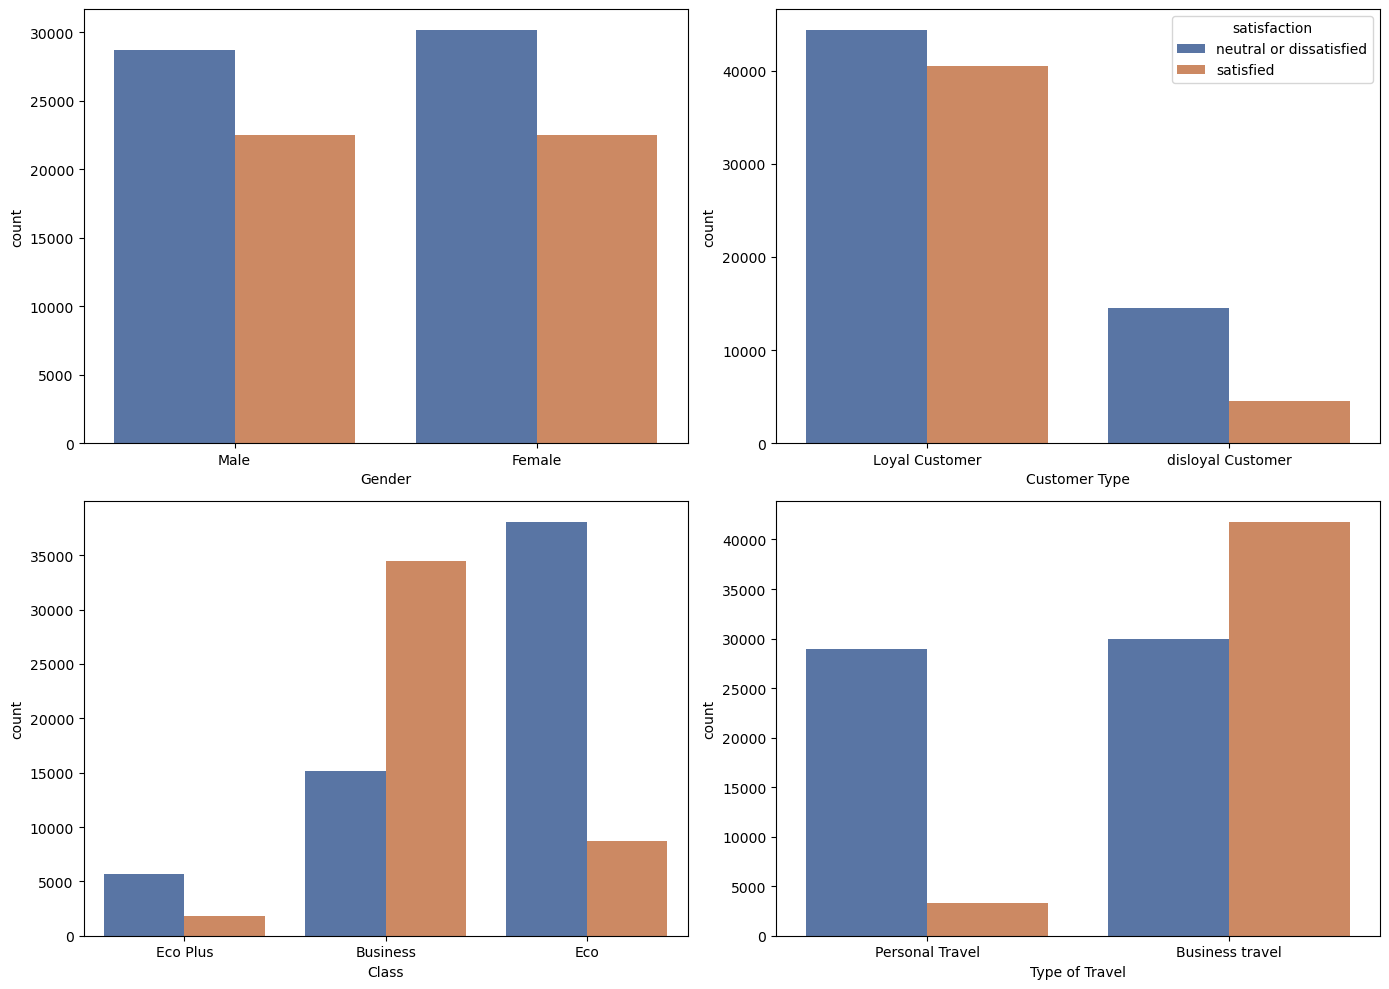

In [12]:
hue_order = ["neutral or dissatisfied", "satisfied"]

palette = {
    "neutral or dissatisfied": "#4C72B0",
    "satisfied": "#DD8452"
}

cat_cols = ["Gender","Customer Type", "Class", "Type of Travel"]
fig, axes = plt.subplots(2,2, figsize=(14, 10))
axes = axes.flatten()

for i,(ax, col) in enumerate(zip(axes,cat_cols)):
    show_legend = True if i == 1 else False
    sns.countplot(ax = ax, data = df_train, x = col, hue = "satisfaction",
                  palette = palette, hue_order = hue_order,legend=show_legend)
                

plt.tight_layout()
plt.show()

나이와 입구 위치, 지연시각은 만족도 여부에 큰 상관 없어보임

지연시각의 경우 이상치 다수 존재

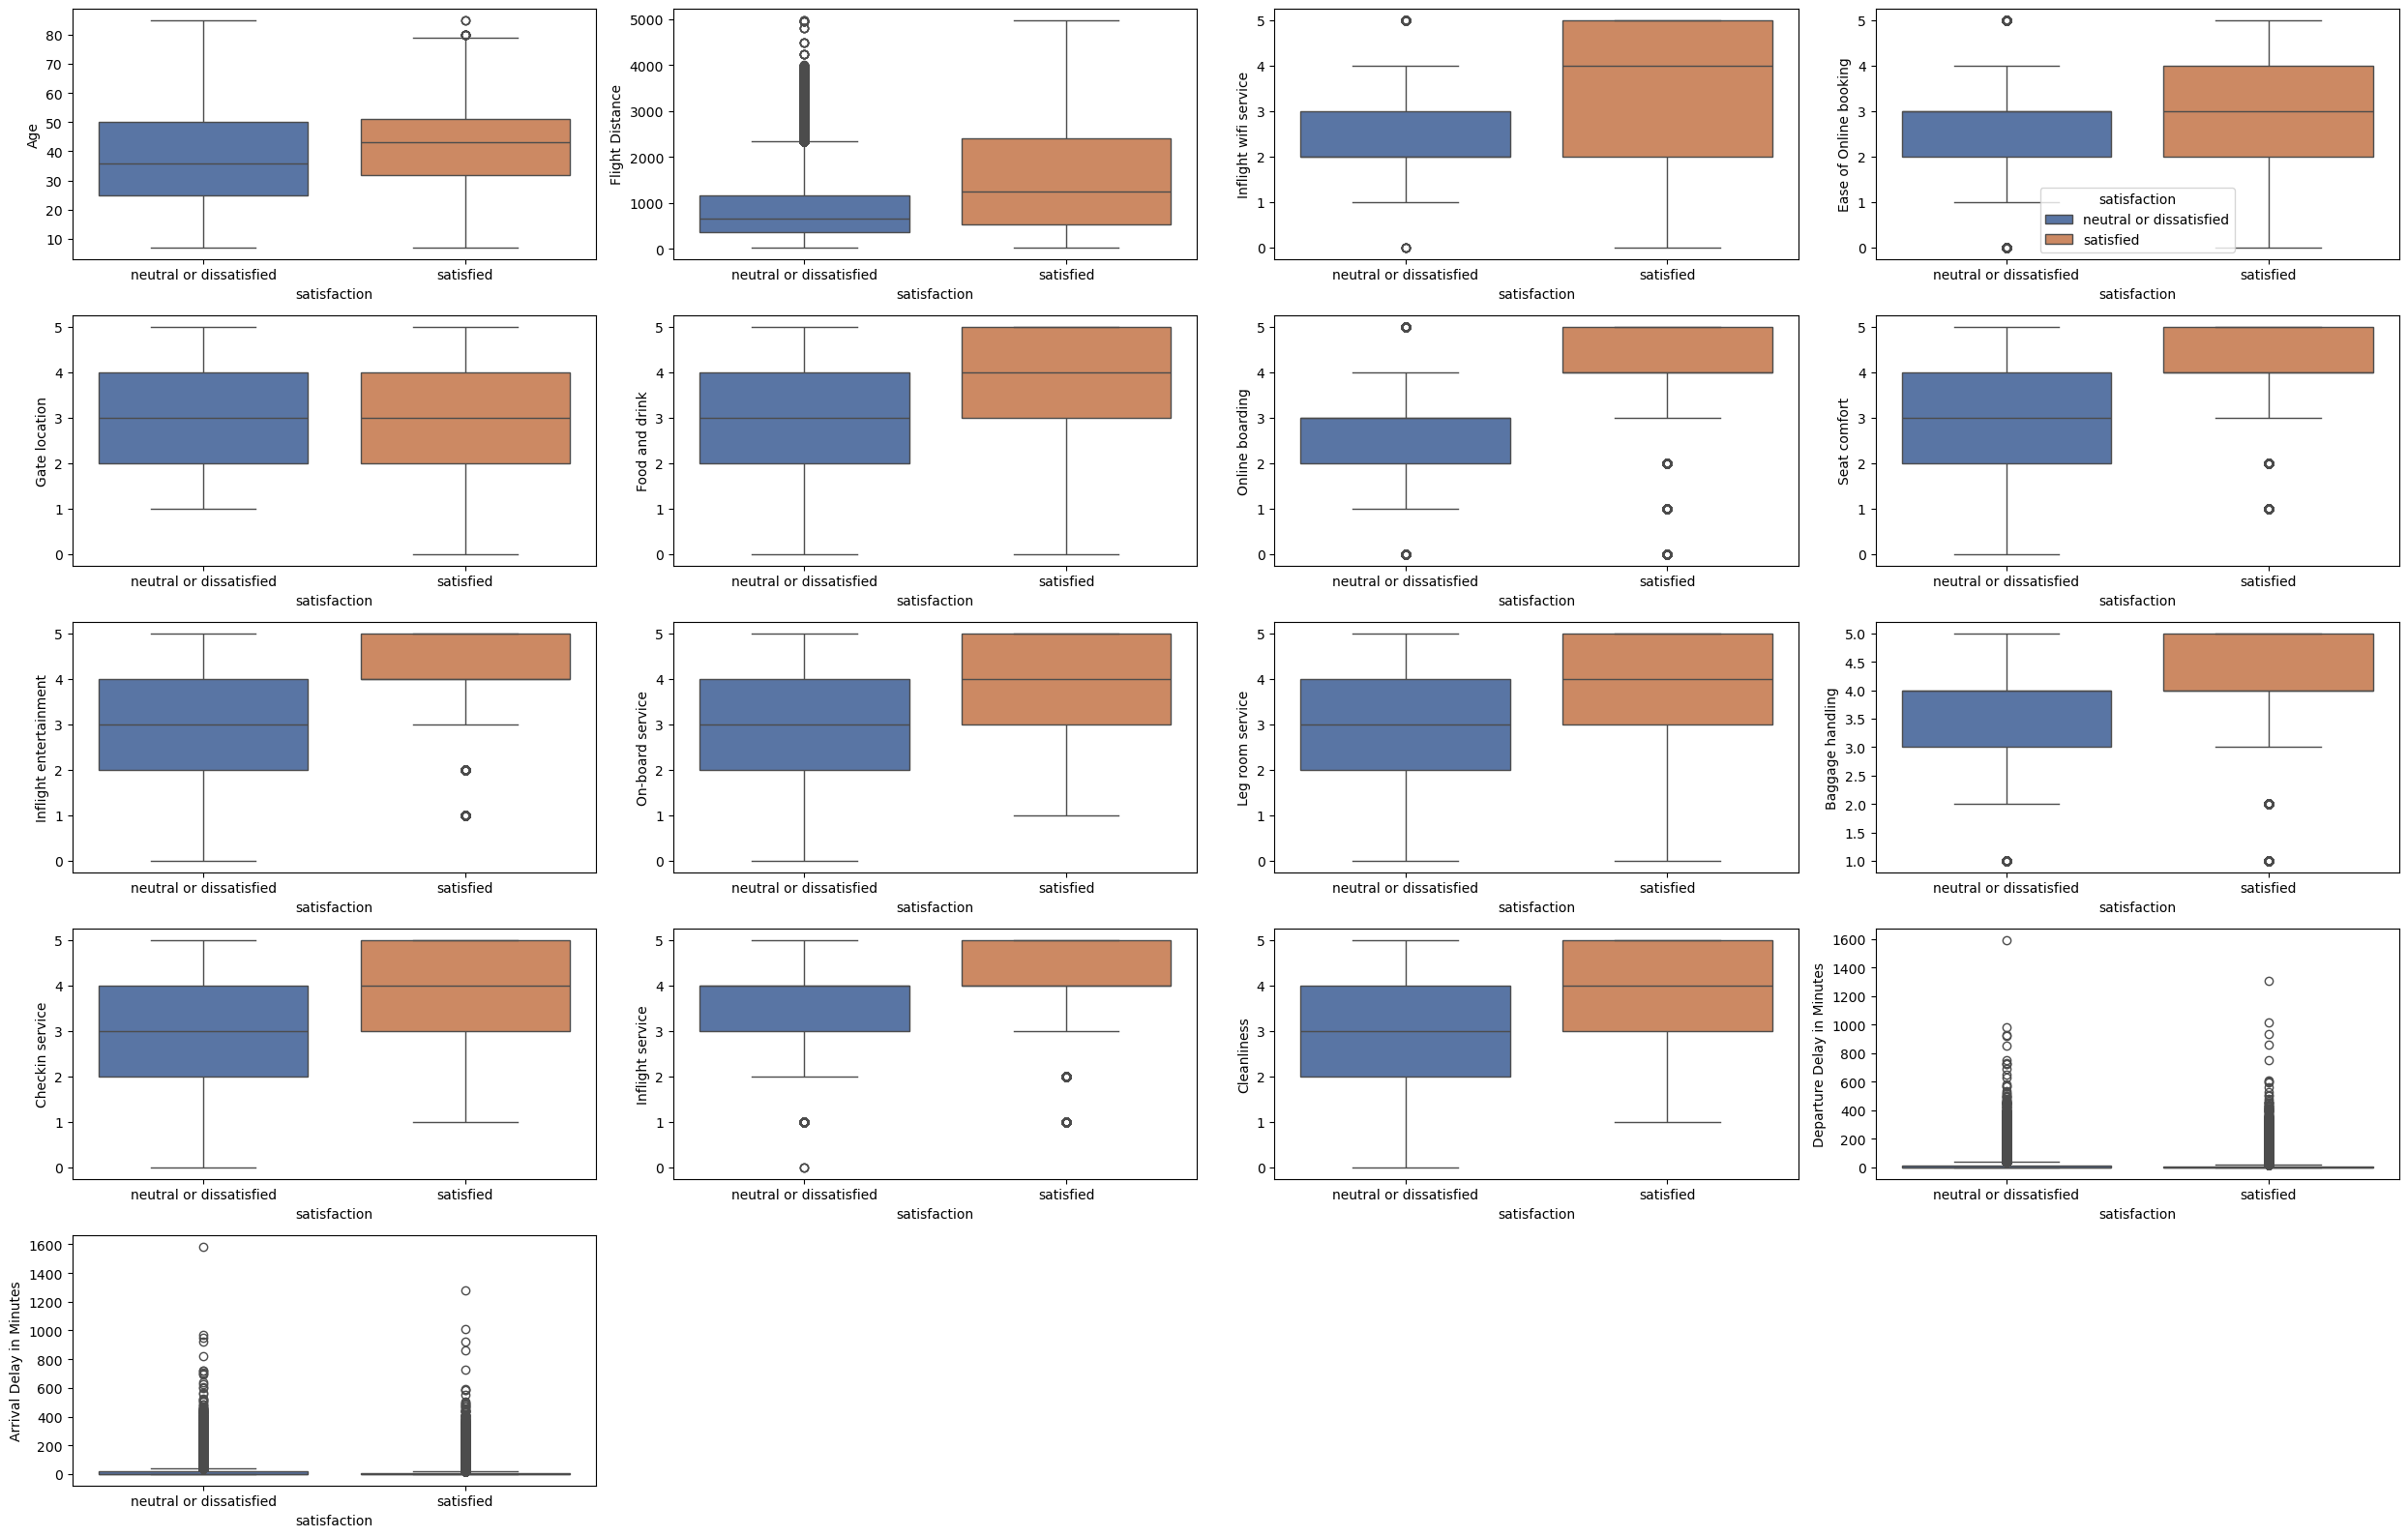

In [13]:
palette = {
    "neutral or dissatisfied": "#4C72B0",
    "satisfied": "#DD8452"
}

columns = [
    "Age", "Flight Distance", "Inflight wifi service", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service", "Baggage handling",
    "Checkin service", "Inflight service", "Cleanliness", "Departure Delay in Minutes","Arrival Delay in Minutes"
]
fig, axes = plt.subplots(5, 4, figsize=(25, 16))
axes = axes.flatten()  

for i,(ax, col) in enumerate(zip(axes,columns)):
    show_legend = True if i == 3 else False
    sns.boxplot(ax = ax, data = df_train, x = "satisfaction", y = col, hue ="satisfaction",
                palette = palette,legend=show_legend)
    
for ax in axes[len(columns):]:
    ax.remove()


plt.tight_layout()
plt.show()

대부분의 변수가 4점을 기준으로 차이를 보임

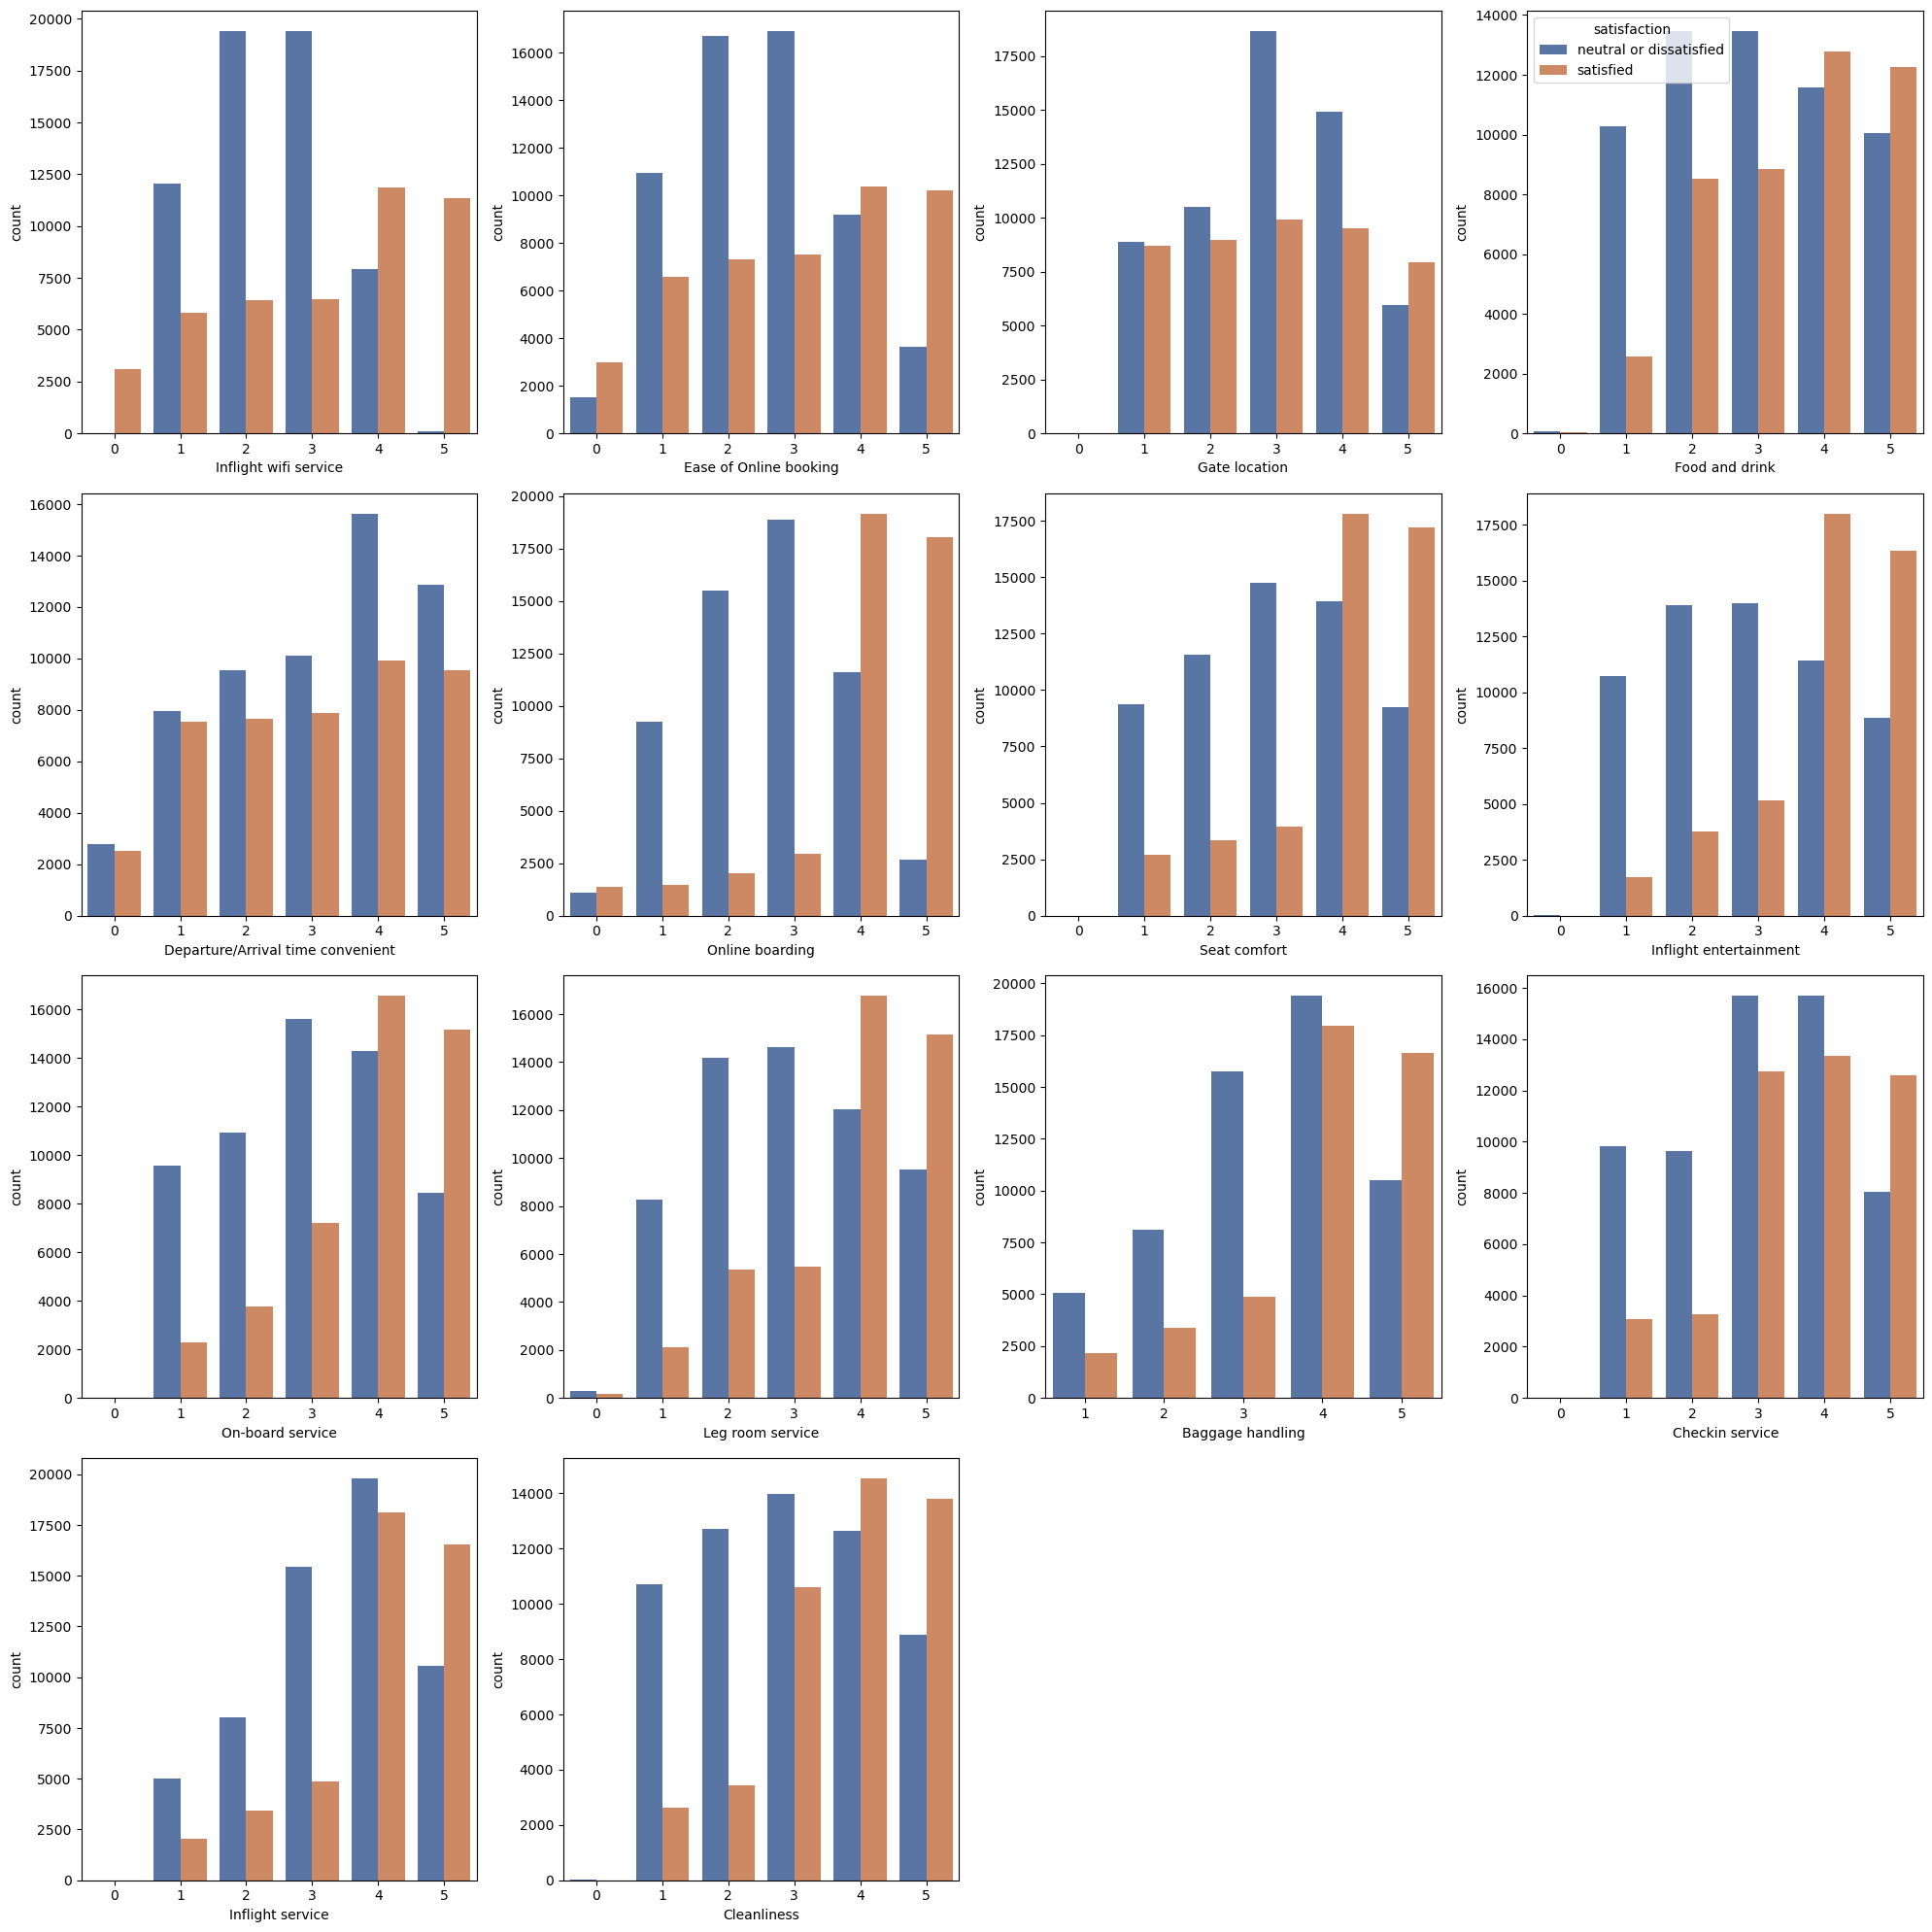

In [14]:
hue_order = ["neutral or dissatisfied", "satisfied"]


palette = {
    "neutral or dissatisfied": "#4C72B0",
    "satisfied": "#DD8452"
}

columns = [
    "Inflight wifi service", "Ease of Online booking", "Gate location", "Food and drink","Departure/Arrival time convenient",
    "Online boarding", "Seat comfort", "Inflight entertainment", "On-board service",
    "Leg room service", "Baggage handling", "Checkin service", "Inflight service",
    "Cleanliness"
]

# 4x4 subplot 생성 (남는 subplot은 제거)
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

# 각 열에 대해 countplot 그리기
for i, (ax, col) in enumerate(zip(axes, columns)):
    # 3 번째 subplot만 legend 켜기, 나머지는 숨기기
    show_legend = True if i == 3 else False
    
    sns.countplot(
        ax=ax,
        data=df_train,
        x=col,
        hue="satisfaction",
        palette=palette,
        hue_order=hue_order,
        legend=show_legend
    )

    
# 남는 subplot 제거
for ax in axes[len(columns):]:
    ax.remove()



plt.tight_layout()
plt.show()

### 이상치 처리
분산을 과도하게 증가시켜 분석 및 모델링 정확도를 감소킴 -> 상한 및 하한 값으로 대치

In [15]:
# 1. 사분위수 계산
Q1 = df_train["Flight Distance"].quantile(0.25)
Q3 = df_train["Flight Distance"].quantile(0.75)
IQR = Q3 - Q1

# 2. 하한값, 상한값 계산
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. 이상치를 하한/상한값으로 대체
df_train["Flight Distance"] = df_train["Flight Distance"].clip(lower=lower_bound, upper=upper_bound)

## 모델 학습

변수의 해석력을 중요시 하기에 로지스틱 회귀분석 선택

In [16]:
df_train.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460.0,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235.0,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142.0,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562.0,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214.0,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [17]:
X_raw = df_train.copy()

from sklearn.model_selection import train_test_split

# 타겟 분리
X = df_train.drop('satisfaction', axis=1)
y = df_train['satisfaction']
y = pd.get_dummies(y, drop_first=True)

# 먼저 나누기
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<베이스라인 모델>

정확도 87%

 AUC: 0.9281358163791855

In [18]:
from sklearn.metrics import accuracy_score, roc_auc_score

# 더미화
X_train_base = pd.get_dummies(X_train_raw, drop_first=True)
X_val_base = pd.get_dummies(X_val_raw, drop_first=True)

# 컬럼 맞추기 (필수)
X_train_base, X_val_base = X_train_base.align(X_val_base, 
                                              join='left', axis=1, fill_value=0)

# 상수항
X_train_base = sm.add_constant(X_train_base)
X_val_base = sm.add_constant(X_val_base)
X_train_base = X_train_base.astype(float)
X_val_base = X_val_base.astype(float)


model_base = sm.Logit(y_train, X_train_base).fit()
pred_base = model_base.predict(X_val_base)
# 0.5 기준으로 클래스 예측
pred_class_base = (pred_base >= 0.5).astype(int)

print("=== Baseline ===")
print("Accuracy:", accuracy_score(y_val, pred_class_base))
print("Baseline AUC:", roc_auc_score(y_val, pred_base))


Optimization terminated successfully.
         Current function value: 0.334595
         Iterations 7
=== Baseline ===
Accuracy: 0.8765218228189211
Baseline AUC: 0.9281358163791855


## <영향력 측면>

wifi service, online boarding, checkin service, class가 만족도에 영향을 크게 주는 것으로 나옴

반면 age, food and drink, gate location은  만족도에 영향이 없어보임

## <해석적 측면의 문제점> 

음식에 대한 만족도가 1점 상승할 때 불만족 대비 만족확률이 2.3% 감소한다는 결과가 나옴

영향력은 어느정도 설명되지만, 그 크기에 대해선 데이터의 특성을 잘 설명하지 못하고 있음

In [19]:
model_base.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              satisfied   No. Observations:                83123
Model:                          Logit   Df Residuals:                    83099
Method:                           MLE   Df Model:                           23
Date:                Wed, 25 Feb 2026   Pseudo R-squ.:                  0.5110
Time:                        14:05:18   Log-Likelihood:                -27813.
converged:                       True   LL-Null:                       -56875.
Covariance Type:            nonrobust   LLR p-value:                     0.000
=====================================================================================================
                                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const                                -5.8419      0.084    -69.719      0.000      -6.006      -5.678
Age                                  -0.0082      0.001    -10.425      0.000      -0.010      -0.007
Flight Distance                   -2.234e-05   1.28e-05     -1.749      0.080   -4.74e-05     2.7e-06
Inflight wifi service                 0.3988      0.013     31.064      0.000       0.374       0.424
Departure/Arrival time convenient    -0.1195      0.009    -13.022      0.000      -0.137      -0.102
Ease of Online booking               -0.1347      0.013    -10.590      0.000      -0.160      -0.110
Gate location                         0.0172      0.010      1.680      0.093      -0.003       0.037
Food and drink                       -0.0237      0.012     -1.981      0.048      -0.047      -0.000
Online boarding                       0.6074      0.011     53.007      0.000       0.585       0.630
Seat comfort                          0.0709      0.012      5.682      0.000       0.046       0.095
Inflight entertainment                0.0571      0.016      3.590      0.000       0.026       0.088
On-board service                      0.2946      0.011     25.942      0.000       0.272       0.317
Leg room service                      0.2555      0.009     26.922      0.000       0.237       0.274
Baggage handling                      0.1429      0.013     11.208      0.000       0.118       0.168
Checkin service                       0.3258      0.010     34.063      0.000       0.307       0.345
Inflight service                      0.1200      0.013      8.965      0.000       0.094       0.146
Cleanliness                           0.2227      0.014     16.466      0.000       0.196       0.249
Departure Delay in Minutes            0.0052      0.001      4.691      0.000       0.003       0.007
Arrival Delay in Minutes             -0.0096      0.001     -8.804      0.000      -0.012      -0.007
Gender_Male                           0.0325      0.022      1.495      0.135      -0.010       0.075
Customer Type_disloyal Customer      -2.0494      0.033    -61.313      0.000      -2.115      -1.984
Type of Travel_Personal Travel       -2.7072      0.035    -77.254      0.000      -2.776      -2.638
Class_Eco                            -0.7452      0.029    -26.044      0.000      -0.801      -0.689
Class_Eco Plus                       -0.8747      0.046    -18.858      0.000      -0.966      -0.784
=====================================================================================================
"""

## 모델 성능 향상

## 다중공선성 확인 
다중공선성 확인결과 출발,도착 지연시간이 공선성을 지님 (VIF>10) -> 변수 해석 어려움을 미칠 수 있음
> 따라서, 출발지연시간을 삭제

In [20]:
# 다중공선성 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산을 위한 함수 정의
def check_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_train_base.columns
    # 각 변수별로 VIF 계산
    vif_data["VIF"] = [variance_inflation_factor(X_train_base.values, i) for i in range(len(X_train_base.columns))]
    return vif_data.sort_values(by="VIF", ascending=False)

# X에 상수항(const)이 포함된 상태에서 실행
print(check_vif(X_train_base))

X_train_raw.drop(columns=["Arrival Delay in Minutes"],inplace = True)

                              feature        VIF
0                               const  54.871795
18           Arrival Delay in Minutes  14.943120
17         Departure Delay in Minutes  14.930710
10             Inflight entertainment   3.894109
16                        Cleanliness   2.885057
5              Ease of Online booking   2.728364
3               Inflight wifi service   2.467927
9                        Seat comfort   2.387650
7                      Food and drink   2.181222
22                          Class_Eco   2.134596
21     Type of Travel_Personal Travel   2.088841
15                   Inflight service   2.070383
8                     Online boarding   2.012522
13                   Baggage handling   1.897093
11                   On-board service   1.773759
4   Departure/Arrival time convenient   1.673494
20    Customer Type_disloyal Customer   1.578276
6                       Gate location   1.504651
2                     Flight Distance   1.367377
12                  

## 변수 구간화
- > 특정 구간 전 후로 만족도 차이가 많이 난다. 이를 모델에 반영하기 위해 특정 구간을 중심으로 파생변수 생성

In [21]:
# 복사 (raw 데이터에서)
X_train_fe = X_train_raw.copy()
X_val_fe = X_val_raw.copy()


# 함수 정의
def categorize_score(x):
    if x <= 1:
        return "bad"
    elif x <= 3:
        return "normal"
    else:
        return "good"

def categorize_score2(x):
    if x <= 3:
        return "bad_or_normal"
    else:
        return "good"


# 적용할 컬럼 목록
cols_score = [
    "Food and drink",
    "Leg room service",
    "Checkin service",
    "Cleanliness"
]

cols_score2 = [
    "Inflight wifi service",
    "Ease of Online booking",
    "Online boarding",
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Baggage handling",
    "Inflight service",
    "Departure/Arrival time convenient"
]


# train / val 모두 동일하게 적용
for col in cols_score:
    X_train_fe[col] = X_train_fe[col].apply(categorize_score)
    X_val_fe[col] = X_val_fe[col].apply(categorize_score)

for col in cols_score2:
    X_train_fe[col] = X_train_fe[col].apply(categorize_score2)
    X_val_fe[col] = X_val_fe[col].apply(categorize_score2)

In [22]:
# 더미화
X_train_fe = pd.get_dummies(X_train_fe, drop_first=True)
X_val_fe = pd.get_dummies(X_val_fe, drop_first=True)

# 컬럼 맞추기
X_train_fe, X_val_fe = X_train_fe.align(
    X_val_fe, join='left', axis=1, fill_value=0
)

# 상수항
X_train_fe = sm.add_constant(X_train_fe)
X_val_fe = sm.add_constant(X_val_fe)

# float 변환
X_train_fe = X_train_fe.astype(float)
X_val_fe = X_val_fe.astype(float)

## 모델 학습

## 개선된 점
정확도 87 % -> 89 % 증가

AUC: 0.92 -> 0.94 증가


In [23]:
#  모델 학습
model_fe = sm.Logit(y_train, X_train_fe).fit(disp=0)

#  확률 예측
pred_prob_fe = model_fe.predict(X_val_fe)

#  0.5 기준 분류
pred_class_fe = (pred_prob_fe >= 0.5).astype(int)

#  성능 출력
print("=== Feature Engineering Model ===")
print("Accuracy:", accuracy_score(y_val, pred_class_fe))
print("AUC:", roc_auc_score(y_val, pred_prob_fe))

=== Feature Engineering Model ===
Accuracy: 0.892786680140513
AUC: 0.9432929018902542


In [24]:
print("\n=== Improvement ===")
print("Accuracy 차이:",
      accuracy_score(y_val, pred_class_fe)
      - accuracy_score(y_val, pred_class_base)) 

print("AUC 차이:",
      roc_auc_score(y_val, pred_prob_fe)
      - roc_auc_score(y_val, pred_base))


=== Improvement ===
Accuracy 차이: 0.016264857321591886
AUC 차이: 0.015157085511068646


## 모델 해석

In [25]:
# 계수
coef = model_fe.params

# 오즈비
odds_ratio = np.exp(coef)

# 95% 신뢰구간 (계수 기준)
conf = model_fe.conf_int()
conf.columns = ["2.5%", "97.5%"]

# OR 테이블 만들기
or_table = pd.DataFrame({
    "coef": coef,
    "odds_ratio": odds_ratio,
    "OR_lower_95%": np.exp(conf["2.5%"]),
    "OR_upper_95%": np.exp(conf["97.5%"]),
    "p_value": model_fe.pvalues
})

# 중요도 테이블 (절대계수 기준)
importance_table = (
    or_table
    .drop(index="const")   # 상수항 제거
    .assign(importance=lambda x: np.abs(x["coef"]))
    .sort_values("importance", ascending=False)
)

importance_table.head(10)

,coef,odds_ratio,OR_lower_95%,OR_upper_95%,p_value,importance
Type of Travel_Personal Travel,-2.670391,0.069225,0.064324,0.074499,0.000000e+00,2.670391
Customer Type_disloyal Customer,-2.116258,0.120482,0.112287,0.129274,0.000000e+00,2.116258
Inflight wifi service_good,1.744948,5.725607,5.335843,6.143841,0.000000e+00,1.744948
Online boarding_good,1.584200,4.875389,4.603579,5.163247,0.000000e+00,1.584200
Class_Eco Plus,-1.030069,0.356982,0.323167,0.394335,1.666624e-91,1.030069
Checkin service_good,0.935191,2.547700,2.358223,2.752400,2.383980e-124,0.935191
Class_Eco,-0.875801,0.416528,0.391792,0.442826,5.648960e-173,0.875801
Leg room service_good,0.797434,2.219838,2.044262,2.410494,3.115998e-80,0.797434
On-board service_good,0.541065,1.717835,1.621121,1.820319,8.176641e-75,0.541065
Seat comfort_good,0.530965,1.700573,1.594951,1.813190,3.122664e-59,0.530965


# 결과 해석

## <항공사의 개선 우선순위 >

### 효과 확실한 것 :
1. 와이파이 : 4점이상 개선시 약 5.08배 불만족대비 만족확률증가

2. 온라인 탑승확인 시스템 : 4점이상으로 개선시 약 5배 증가

3. 공항 내 체크인 시스템 : 4점이상 개선시 약 2.46배 증가 

### 그 후 개선하면 긍정적인 것 : 
4. 확실한 다리공간 넓이 확보, : 약 2.23배 증가

5. 좌석 편암함 : 약 1.65배 증가

6. 수하물 처리 : 약 1.61배 증가


### 못바꾸지만 큰 영향 미치는 것: 
1. 여행 목적 : 비즈니스가 14.6배 증가
2. 고객 충성도 : 충성고객이 8.46배 증가
3. 좌석 등급 : 비즈니스가 이코노비에 비해 2.41배 증가


# <세부사항>
## 1. 여행목적 

비즈니스 여행객은 개인 여행객보다 만족할 확률 14.5배 높다.
    
## 2. 고객 충성도

 충성 고객은 비충성 고객보다 약 8.34배 만족확률 높다.

## 3. 기내 와이파이 서비스

기내 와이파이가 4점이상인 경우가 그렇지 않은 경우에 비해 약 5.72배 증가한다.

→ 와이파이는 확실한 개선이 필요

## 4. 온라인 탑승확인

온라인 탑승확인이 4점이상인 경우가 그렇지 않은 경우에 비해 약 4.87배 증가한다.

--> 어플로 온라인 탑승확인을 확실히 좋게 해야 한다.


## 5. 비즈니스와 이코노미플러스, 이코노미 티켓

비즈니스 클래스 승객은 이코노미 plus 승객보다  2.79배 만족확률 높다.

비즈니스 클래스 승객은 이코노미 승객보다 약 2.4배 만족확률 높다.

## 6. 공항 체크인 서비스

bad → good : 2.56배 증가

bad → normal : 1.68배 증가

->체크인서비스는 확실히 좋아질 수록 만족도에 영향을 미친다.

## 7. 래그 룸 서비스 (leg room service)

레그 룸 서비스 점수가 4\~5점인 집단은 0\~1점인 집단 대비
만족할 오즈가 약 2.22배 높다.

레그 룸 서비스 를 2\~3점으로 평가한 집단은  0\~1점인 집단 대비
만족할 오즈가 약 1.13배 높다.

--> 애매하게 다리공간을 늘리는 것보다 확실히 늘리는 것이 중요하다.

## 8. On-board service

on-board 서비스가 4\~5점인 경우
0\~3점인 경우보다 만족 가능성이 약 1.72배 높다.

## 9. 좌석편안함(seat comfort)

좌석 편안함을 4\~5점으로 평가한 집단은 0\~3점으로 평가한 집단 대비
만족할 오즈가 약 1.70배 높다.

-> 애매하게 늘리는것 보다 확실히 늘려야 1.70배정도 더 만족한다.

## 10. 수하물 처리 (baggage handling)

수하물 처리를  4\~5점으로 평가한 집단은 0\~3점으로 평가한 집단 대비
만족할 오즈가 약 1.63배 높다.


## 11. 기내 서비스(inflight service)

기내 서비스를  4\~5점으로 평가한 집단은 0\~3점으로 평가한 집단 대비
만족할 오즈가 약 1.62배 높다.


## 12. 기내 청결도 (Cleanliness)

bad → good : 1.65배 

bad → normal : 1.30배 
→ 기본적 청결 확보는 중요하지만 폭발적 영향은 아님

## 13. 기내 식음료 (Food and drink)

bad → good : 1.05배 (pvalue > 0.05이므로 통계적으로 유의하지않음)

bad → normal : 1.19배 

--> 식음료는 기내 만족도에 큰 영향을 주지 못함

## 14. 출발 및 도착시간의 편리성(Departure/Arrival time convenient)
이전 대비 약 0.64배 수준으로 감소한다.

->여행 목적, 좌석 등급, 서비스 품질 등 강한 변수들을 통제한 이후에는 시간 편리성의 순수 효과가 상대적으로 약해지거나 방향이 조정된 결과로 해석할 수 있다.
## 15. 온라인 예약 (Ease of Online booking)

온라인 예약을 4~5점으로 평가한 경우
만족 오즈는 1.01배가 된다.
통계적으로 유의하지 않으며 영향은 거의 없다.

## 16. Gate location
만족 오즈가 약 0.92배로 소폭 감소한다.
통계적으로는 유의하지만, 영향력은 크지 않다.

## 17. 성별
남성은 여성 대비
만족 오즈가 1.02배이다.

통계적으로 유의하지 않다.

## 18. 나이
나이 1세 증가할 때마다 만족 오즈는 0.993배가 된다.
약 0.7% 감소 효과로, 실질적인 영향은 매우 작다.

## 19. Inflight entertainment

OR = 0.9948

4~5점 평가 시
만족 오즈는 0.995배이다.

1배와 거의 동일하며 유의하지 않다.

## 20. 도착지연시간 (Departure Delay in Minutes)

지연 1분 증가할 때마다
만족 오즈는 0.996배가 된다.

1배에 매우 가까워 영향은 작다.

## 21. 비행거리 (Flight Distance)

OR = 1.000013

비행거리 1단위 증가 시
만족 오즈는 1.000013배이다.

사실상 1배로, 영향이 없다고 볼 수 있다.

